In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [25]:
statlog_data = fetch_ucirepo(id=144)
X = statlog_data.data.features.copy()
y = statlog_data.data.targets.copy()
print(X.head())
print(y.head())

  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   
3        A74           2        A93        A103            4        A122   
4        A73           3        A93        A101            4        A124   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           67        A1

In [26]:
column_mapping = {
'Attribute1': 'checking_status', 'Attribute2': 'duration_months', 'Attribute3': 'credit_history',
'Attribute4': 'purpose', 'Attribute5': 'credit_amount', 'Attribute6': 'savings_account',
'Attribute7': 'employment_since', 'Attribute8': 'installment_rate', 'Attribute9': 'status_sex',
'Attribute10': 'other_debtors', 'Attribute11': 'residence_since', 'Attribute12': 'property',
'Attribute13': 'age', 'Attribute14': 'other_installment_plans', 'Attribute15': 'housing',
'Attribute16': 'num_existing_credits', 'Attribute17': 'job', 'Attribute18': 'liable_people',
'Attribute19': 'telephone', 'Attribute20': 'foreign_worker'
}
X.rename(columns=column_mapping, inplace=True)

y = y['class'].map({1: 0, 2: 1})

In [27]:
print(X.head())
print(y.head())

  checking_status  duration_months credit_history purpose  credit_amount  \
0             A11                6            A34     A43           1169   
1             A12               48            A32     A43           5951   
2             A14               12            A34     A46           2096   
3             A11               42            A32     A42           7882   
4             A11               24            A33     A40           4870   

  savings_account employment_since  installment_rate status_sex other_debtors  \
0             A65              A75                 4        A93          A101   
1             A61              A73                 2        A92          A101   
2             A61              A74                 2        A93          A101   
3             A61              A74                 2        A93          A103   
4             A61              A73                 3        A93          A101   

   residence_since property  age other_installment_plans

In [28]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y)

# **LOGISTIQUE REGRESSION**


Performance Régression Logistique (Seuil 0.5):
              precision    recall  f1-score   support

  Fiable (0)       0.89      0.73      0.80       175
  Risqué (1)       0.56      0.80      0.66        75

    accuracy                           0.75       250
   macro avg       0.72      0.76      0.73       250
weighted avg       0.79      0.75      0.76       250



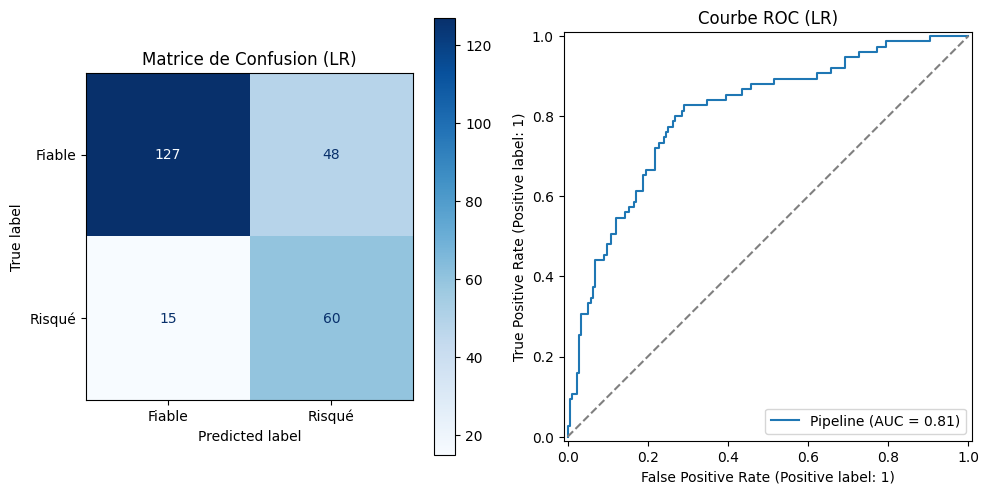

In [29]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
print("\nPerformance Régression Logistique (Seuil 0.5):")
print(classification_report(y_test, y_pred_lr, target_names=['Fiable (0)', 'Risqué (1)']))
# Affichage de la matrice de confusion et de la courbe ROC
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', display_labels=['Fiable', 'Risqué'], ax=plt.gca())
plt.title("Matrice de Confusion (LR)")
plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(pipeline_lr, X_test, y_test, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"Courbe ROC (LR)")
plt.tight_layout()
plt.show()

# **RANDOM FOREST**

In [30]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

In [31]:
from sklearn.metrics import recall_score, precision_score

#Test Initial (Seuil 0.5)
y_pred_rf_default = (y_proba_rf >= 0.5).astype(int)
print("\nPerformance Random Forest (Seuil 0.5):")
print(classification_report(y_test, y_pred_rf_default, target_names=['Fiable (0)', 'Risqué (1)']))
#Calibration Séquentielle
print("AJUSTEMENT STRATÉGIQUE DU SEUIL (Threshold Tuning)")
seuil_tests = [0.30, 0.35, 0.40]
# Simulation des tests séquentiels
resultats = {}

for seuil in seuil_tests:
    y_pred_tuned = (y_proba_rf >= seuil).astype(int)


    report = classification_report(y_test, y_pred_tuned, target_names=['Fiable (0)', 'Risqué (1)'], output_dict=True)
    resultats[seuil] = report


    print(f"\nPerformance Random Forest (Seuil {seuil:.2f}):")
    print(classification_report(y_test, y_pred_tuned, target_names=['Fiable (0)', 'Risqué (1)']))


Performance Random Forest (Seuil 0.5):
              precision    recall  f1-score   support

  Fiable (0)       0.79      0.93      0.85       175
  Risqué (1)       0.70      0.41      0.52        75

    accuracy                           0.77       250
   macro avg       0.75      0.67      0.69       250
weighted avg       0.76      0.77      0.75       250

AJUSTEMENT STRATÉGIQUE DU SEUIL (Threshold Tuning)

Performance Random Forest (Seuil 0.30):
              precision    recall  f1-score   support

  Fiable (0)       0.87      0.67      0.76       175
  Risqué (1)       0.50      0.77      0.61        75

    accuracy                           0.70       250
   macro avg       0.69      0.72      0.69       250
weighted avg       0.76      0.70      0.72       250


Performance Random Forest (Seuil 0.35):
              precision    recall  f1-score   support

  Fiable (0)       0.86      0.76      0.81       175
  Risqué (1)       0.56      0.72      0.63        75

    accur


RECHERCHE SYSTÉMATIQUE DU MEILLEUR SEUIL (Threshold Tuning)

Le meilleur seuil trouvé pour maximiser le F1-score (classe Risqué) est : 0.33
F1-score optimal pour la classe Risqué : 0.64

Performance Random Forest (Seuil Optimal F1):
              precision    recall  f1-score   support

  Fiable (0)       0.88      0.74      0.80       175
  Risqué (1)       0.55      0.76      0.64        75

    accuracy                           0.74       250
   macro avg       0.72      0.75      0.72       250
weighted avg       0.78      0.74      0.75       250



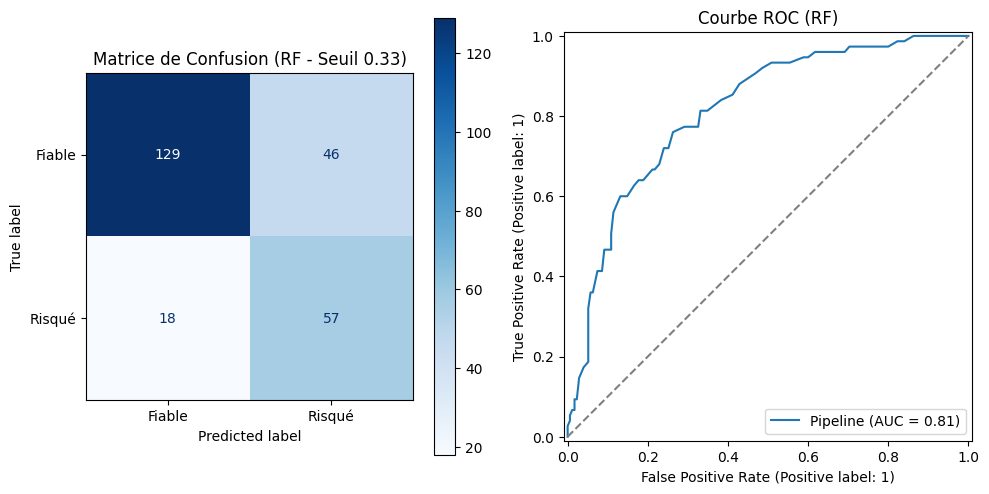

In [32]:
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# Assuming pipeline_rf, X_test, y_test, y_proba_rf are already defined and available from previous steps

# Recherche systématique du meilleur seuil (Threshold Tuning)
print("\nRECHERCHE SYSTÉMATIQUE DU MEILLEUR SEUIL (Threshold Tuning)")
seuil_optimal = 0
f1_max = 0

# Test d'une plage de seuils de 0.01 à 0.99
for seuil in np.arange(0.01, 1.0, 0.01):
    y_pred_tuned = (y_proba_rf >= seuil).astype(int)
    # Nous nous concentrons sur la classe positive (Risqué = 1)
    f1 = f1_score(y_test, y_pred_tuned, pos_label=1)
    if f1 > f1_max:
        f1_max = f1
        seuil_optimal = seuil

y_pred_optimal = (y_proba_rf >= seuil_optimal).astype(int)

print(f"\nLe meilleur seuil trouvé pour maximiser le F1-score (classe Risqué) est : {seuil_optimal:.2f}")
print(f"F1-score optimal pour la classe Risqué : {f1_max:.2f}")
print("\nPerformance Random Forest (Seuil Optimal F1):")
print(classification_report(y_test, y_pred_optimal, target_names=['Fiable (0)', 'Risqué (1)']))

# Affichage de la matrice de confusion et de la courbe ROC pour le seuil optimal
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal, cmap='Blues', display_labels=['Fiable', 'Risqué'], ax=plt.gca())
plt.title(f"Matrice de Confusion (RF - Seuil {seuil_optimal:.2f})")

plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(pipeline_rf, X_test, y_test, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f"Courbe ROC (RF)")
plt.tight_layout()
plt.show()

In [33]:
# 1. Extraction du classifieur
rf_model = pipeline_rf.named_steps['clf']
# 2. Obtention des noms de colonnes après One-Hot Encoding
ohe = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat']
feature_names_cat = ohe.get_feature_names_out(categorical_features)
all_features = np.concatenate([numeric_features, feature_names_cat])
# 3. Extraction et tri des importances
importances = rf_model.feature_importances_
feature_importances = pd.Series(importances, index=all_features).sort_values(ascending=False)
# 4. Affichage
print("\n--- Top 10 des Importances de Variables (Random Forest) ---")
print(feature_importances.head(10).to_markdown())


--- Top 10 des Importances de Variables (Random Forest) ---
|                     |         0 |
|:--------------------|----------:|
| credit_amount       | 0.088052  |
| duration_months     | 0.0764283 |
| age                 | 0.0742748 |
| checking_status_A14 | 0.0695666 |
| installment_rate    | 0.034843  |
| checking_status_A11 | 0.0341393 |
| residence_since     | 0.0327772 |
| savings_account_A61 | 0.025061  |
| credit_history_A34  | 0.0245244 |
| checking_status_A12 | 0.0197428 |


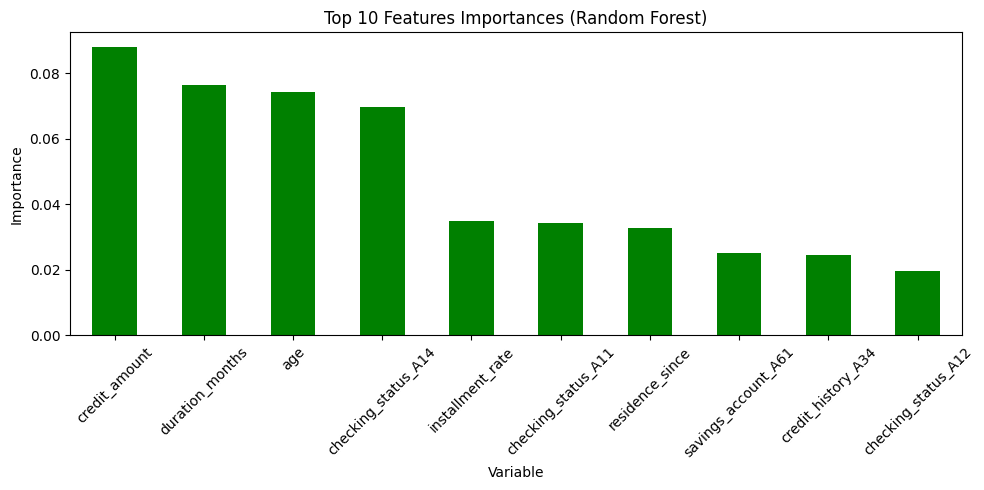

In [34]:
plt.figure(figsize=(10, 5))
feature_importances.head(10).plot(kind='bar', color='green')
plt.title("Top 10 Features Importances (Random Forest)")
plt.xlabel("Variable")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nombre de Faux Négatifs analysés : 18

--- Distribution du 'Checking Status' chez les Faux Négatifs ---
checking_status
A14    0.444444
A12    0.333333
A11    0.166667
A13    0.055556
Name: proportion, dtype: float64


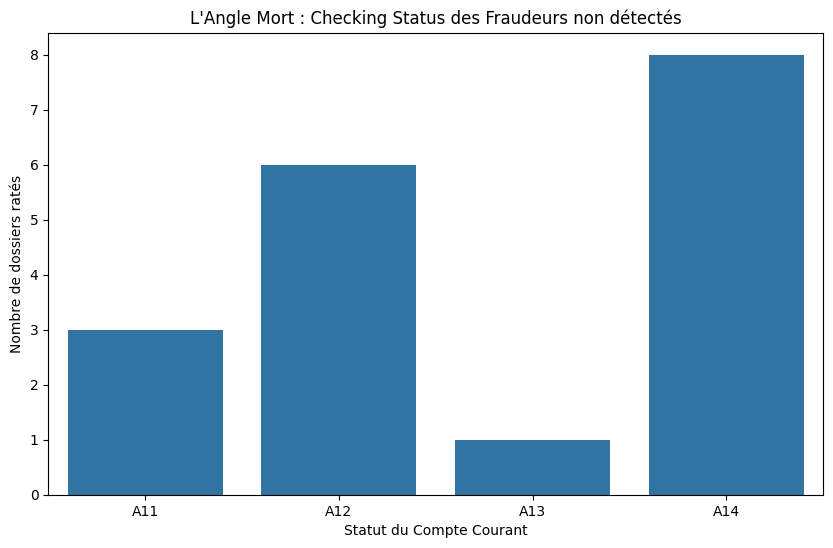


--- Croisement Checking Status vs Job pour les Faux Négatifs ---
job              A172  A173  A174
checking_status                  
A11                 0     3     0
A12                 1     3     2
A13                 1     0     0
A14                 1     5     2


In [35]:
# 1. Récupération des indices des Faux Négatifs (Vrais = 1, Prédictions = 0)
# Assure-toi d'utiliser le y_pred correspondant à ton 'seuil_optimal' (ou le modèle par défaut si tu préfères)
indices_fn = y_test[(y_test == 1) & (y_pred_optimal == 0)].index

# 2. Extraction des données brutes pour ces erreurs spécifiques
# On regarde X_test (avant transformation) pour lire les vraies valeurs
faux_negatifs = X_test.loc[indices_fn]

# 3. Analyse de la variable coupable : checking_status
print(f"Nombre de Faux Négatifs analysés : {len(faux_negatifs)}")
print("\n--- Distribution du 'Checking Status' chez les Faux Négatifs ---")
print(faux_negatifs['checking_status'].value_counts(normalize=True))

# 4. Visualisation pour que ce soit incontestable
plt.figure(figsize=(10, 6))
sns.countplot(data=faux_negatifs, x='checking_status', order=sorted(faux_negatifs['checking_status'].unique()))
plt.title("L'Angle Mort : Checking Status des Fraudeurs non détectés")
plt.xlabel("Statut du Compte Courant")
plt.ylabel("Nombre de dossiers ratés")
plt.show()

# 5. Vérification croisée avec l'Emploi (Job) et l'Historique
# Est-ce qu'on a raté des chômeurs parce qu'ils avaient un compte positif ?
print("\n--- Croisement Checking Status vs Job pour les Faux Négatifs ---")
print(pd.crosstab(faux_negatifs['checking_status'], faux_negatifs['job']))

--- COMPARATIF FAUX NÉGATIFS ---
Random Forest (Optimisé) a raté : 18 dossiers (approx)
Régression Logistique a raté : 15 dossiers

--- Distribution du 'Checking Status' chez les erreurs de la LR ---
checking_status
A14    0.466667
A11    0.266667
A12    0.133333
A13    0.133333
Name: proportion, dtype: float64


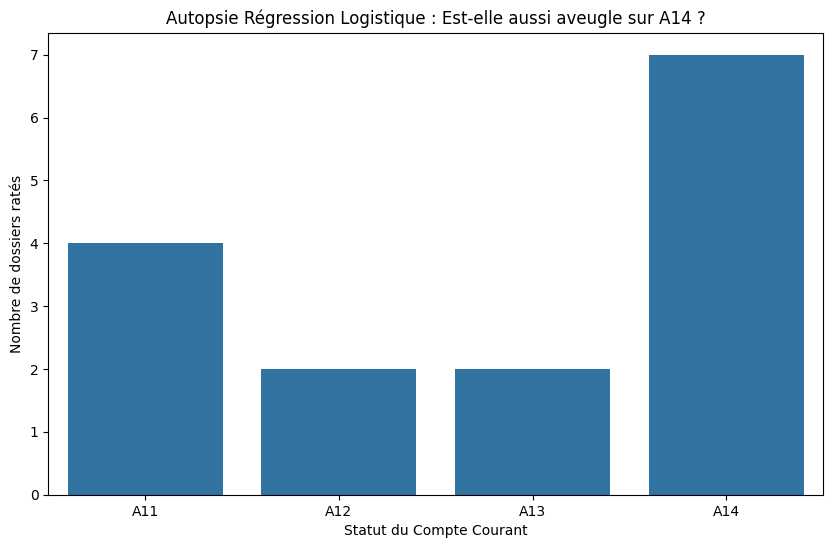

In [36]:
# 1. Récupération des indices des Faux Négatifs pour la RÉGRESSION LOGISTIQUE
# On utilise y_pred_lr (calculé au seuil 0.5 par défaut ou ton pipeline)
indices_fn_lr = y_test[(y_test == 1) & (y_pred_lr == 0)].index

# 2. Extraction des données
faux_negatifs_lr = X_test.loc[indices_fn_lr]

# 3. Comparaison brutale
print(f"--- COMPARATIF FAUX NÉGATIFS ---")
print(f"Random Forest (Optimisé) a raté : 18 dossiers (approx)")
print(f"Régression Logistique a raté : {len(faux_negatifs_lr)} dossiers")

print("\n--- Distribution du 'Checking Status' chez les erreurs de la LR ---")
print(faux_negatifs_lr['checking_status'].value_counts(normalize=True))

# 4. Visuel pour trancher
plt.figure(figsize=(10, 6))
sns.countplot(data=faux_negatifs_lr, x='checking_status', order=sorted(faux_negatifs_lr['checking_status'].unique()))
plt.title("Autopsie Régression Logistique : Est-elle aussi aveugle sur A14 ?")
plt.xlabel("Statut du Compte Courant")
plt.ylabel("Nombre de dossiers ratés")
plt.show()

--- OPTIMISATION FINANCIÈRE ---
Seuil par défaut (0.5) coût estimé : 123
Seuil Optimal Business : 0.47000000000000003
Coût minimal possible : 116


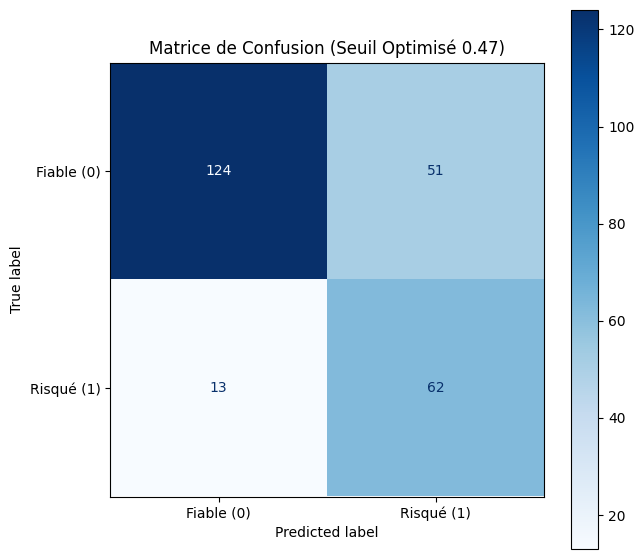

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Obtenir les probabilités brutes (pas les 0/1)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

# 2. Définir tes coûts (C'est toi le patron, ajuste ces valeurs)
COUT_FN = 5  # Perdre le capital prêté (C'est grave)
COUT_FP = 1   # Manquer un client (C'est dommage, mais moins grave)

# 3. Boucle pour trouver le seuil qui coûte le moins cher
seuils = np.arange(0.0, 1.0, 0.01)
couts = []

for seuil in seuils:
    pred_seuil = (y_proba_lr >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_seuil).ravel()

    # Formule du coût total
    cout_total = (fn * COUT_FN) + (fp * COUT_FP)
    couts.append(cout_total)

# 4. Résultat
meilleur_index = np.argmin(couts)
seuil_optimal = seuils[meilleur_index]

print(f"--- OPTIMISATION FINANCIÈRE ---")
print(f"Seuil par défaut (0.5) coût estimé : {couts[50]}") # Index 50 correspond à 0.5
print(f"Seuil Optimal Business : {seuil_optimal}")
print(f"Coût minimal possible : {couts[meilleur_index]}")

# 5. Appliquer ce seuil
y_pred_optimal = (y_proba_lr >= seuil_optimal).astype(int)
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Fiable (0)', 'Risqué (1)'])

disp.plot(cmap='Blues', ax=ax, values_format='d') # Le format 'd' assure des entiers
plt.title(f"Matrice de Confusion (Seuil Optimisé {seuil_optimal:.2f})")
plt.show()